In [1]:
# If running in a fresh environment, this cell will ensure needed packages are available.
import sys, subprocess

def ensure(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0].split("<=")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Core scientific stack
for p in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "seaborn"]:
    ensure(p)

# XGBoost
ensure("xgboost")

print("All dependencies present.")

All dependencies present.


In [2]:
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional

from scipy.stats import skew, kurtosis, shapiro, t as student_t, ttest_rel
from scipy.signal import welch

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------
# CONFIGURATION
# -----------------
BASE_DIR = r"C:\Users\tamin\Documents\Masterarbeit 2025\Implementierung Algortihmen\archive\Schizophrenia"
N_SPLITS = 5
RANDOM_STATE = 42
SAMPLING_RATE: Optional[float] = None  # e.g., 250.0 if known; improves band features
MIN_SAMPLES_PER_FILE = 16  # guard for extremely short files

# Windowing (use *_SEC if SAMPLING_RATE is provided; otherwise, sample-based)
WINDOW_SEC = 5.0
STEP_SEC = 2.5
WINDOW_SAMPLES = 1024
STEP_SAMPLES = 512

# SVM feature selection
K_FEATURES_SVM = 128  # top-k features via mutual information; auto-clipped to feature count

# Reproducibility
np.random.seed(RANDOM_STATE)

assert os.path.isdir(BASE_DIR), f"Base directory not found: {BASE_DIR}"
assert os.path.isdir(os.path.join(BASE_DIR, "norm")), f"Missing folder: {os.path.join(BASE_DIR, 'norm')}"
assert os.path.isdir(os.path.join(BASE_DIR, "sch")), f"Missing folder: {os.path.join(BASE_DIR, 'sch')}"

In [3]:
def _looks_binary(path: str, num_bytes: int = 2048) -> bool:
    with open(path, "rb") as f:
        chunk = f.read(num_bytes)
    if b"\x00" in chunk:
        return True
    printable = sum(32 <= b <= 126 or b in (9, 10, 13) for b in chunk)
    return printable / max(1, len(chunk)) < 0.85

def load_eea(path: str) -> np.ndarray:
    """
    Returns an array of shape (n_samples, n_channels).
    Tries delimited text first; falls back to raw float32 binary (single-channel).
    """
    if not _looks_binary(path):
        try:
            df = pd.read_csv(
                path, sep=None, engine="python", header=None, comment="#",
                na_values=["NA", "NaN", ""]
            )
            arr = df.dropna(axis=1, how="all").to_numpy(dtype=float)
            if arr.ndim == 1:
                arr = arr.reshape(-1, 1)
            return arr
        except Exception:
            pass

    with open(path, "rb") as f:
        raw = f.read()
    n4 = len(raw) // 4
    if n4 == 0:
        raise ValueError(f"Cannot parse {path} as text or float32 binary.")
    arr = np.frombuffer(raw[: n4 * 4], dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr

def list_files() -> Tuple[List[str], List[str]]:
    norm_dir = os.path.join(BASE_DIR, "norm")
    sch_dir = os.path.join(BASE_DIR, "sch")
    norm_files = [os.path.join(norm_dir, f) for f in os.listdir(norm_dir) if f.lower().endswith(".eea")]
    sch_files  = [os.path.join(sch_dir, f)  for f in os.listdir(sch_dir)  if f.lower().endswith(".eea")]
    norm_files.sort()
    sch_files.sort()
    return norm_files, sch_files

norm_files, sch_files = list_files()
print(f"Found {len(norm_files)} norm files and {len(sch_files)} sch files.")
assert len(norm_files) > 0 and len(sch_files) > 0, "No .eea files found in one or both folders."

Found 39 norm files and 45 sch files.


In [4]:
def zero_crossings(x: np.ndarray) -> float:
    x = np.asarray(x)
    return float(np.sum(np.diff(np.signbit(x)) != 0) / max(1, len(x) - 1))

def median_abs_dev(x: np.ndarray) -> float:
    m = np.median(x)
    return float(np.median(np.abs(x - m)))

def hjorth_params(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0 = np.var(x, ddof=1) if len(x) > 1 else np.var(x)
    var1 = np.var(dx, ddof=1) if len(dx) > 1 else np.var(dx)
    var2 = np.var(ddx, ddof=1) if len(ddx) > 1 else np.var(ddx)
    activity = var0
    mobility = np.sqrt(var1 / var0) if var0 > 0 else np.nan
    complexity = np.sqrt(var2 / var1) / mobility if var1 > 0 and mobility not in (0, np.nan) else np.nan
    return float(activity), float(mobility), float(complexity)

def line_length(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float).ravel()
    if len(x) < 2:
        return 0.0
    return float(np.sum(np.abs(np.diff(x))) / (len(x) - 1))

In [5]:
def spectral_features(x: np.ndarray, fs: Optional[float]) -> Dict[str, float]:
    if len(x) < 8:
        return {"spec_centroid": np.nan, "spec_entropy": np.nan, "spec_low_high_ratio": np.nan}
    f, pxx = welch(x, fs=fs if fs is not None else 1.0, nperseg=min(256, len(x)))
    p = pxx / np.sum(pxx) if np.sum(pxx) > 0 else pxx
    centroid = float(np.sum(f * p) / np.sum(p)) if np.sum(p) > 0 else np.nan
    eps = 1e-12
    entropy = float(-np.sum(p * np.log(p + eps)) / np.log(len(pxx))) if len(pxx) > 1 else np.nan
    mid = len(pxx) // 2
    low = float(np.sum(pxx[:mid])) if mid > 0 else np.nan
    high = float(np.sum(pxx[mid:])) if mid > 0 else np.nan
    ratio = float(low / high) if high and np.isfinite(high) and high > 0 else np.nan
    return {"spec_centroid": centroid, "spec_entropy": entropy, "spec_low_high_ratio": ratio}

def _bands(fs: Optional[float]):
    if fs is None:
        # 5 equal-width pseudo-bands in normalized freq (0..Nyquist)
        return [("b1", 0.00, 0.10), ("b2", 0.10, 0.20), ("b3", 0.20, 0.30), ("b4", 0.30, 0.40), ("b5", 0.40, 0.50)]
    nyq = fs / 2.0
    return [
        ("delta", 0.5, 4.0),
        ("theta", 4.0, 8.0),
        ("alpha", 8.0, 13.0),
        ("beta", 13.0, 30.0),
        ("gamma", 30.0, min(45.0, nyq*0.9)),
    ]

def bandpowers(x: np.ndarray, fs: Optional[float]) -> Dict[str, float]:
    if len(x) < 8:
        return {}
    if fs is None:
        # compute over normalized frequency
        f, pxx = welch(x, fs=1.0, nperseg=min(256, len(x)))
    else:
        f, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))
    total_power = np.trapz(pxx, f)
    feats = {}
    for name, lo, hi in _bands(fs):
        if fs is None:
            # lo/hi are fractions of Nyquist (already 0..0.5)
            lo_f, hi_f = lo, hi
        else:
            lo_f, hi_f = lo, hi
        mask = (f >= lo_f) & (f < hi_f)
        bp = np.trapz(pxx[mask], f[mask]) if np.any(mask) else 0.0
        feats[f"bp_{name}_abs"] = float(bp)
        feats[f"bp_{name}_rel"] = float(bp / total_power) if total_power > 0 else np.nan
    return feats

In [6]:
def extract_channel_features(x: np.ndarray, fs: Optional[float], prefix: str) -> Dict[str, float]:
    x = np.asarray(x).astype(float).ravel()
    feats = {}
    if len(x) < MIN_SAMPLES_PER_FILE:
        base = {
            "mean": np.nan, "std": np.nan, "min": np.nan, "max": np.nan, "range": np.nan,
            "skew": np.nan, "kurt": np.nan, "q10": np.nan, "q25": np.nan, "q50": np.nan,
            "q75": np.nan, "q90": np.nan, "energy": np.nan, "mad": np.nan, "zcr": np.nan,
            "hj_activity": np.nan, "hj_mobility": np.nan, "hj_complexity": np.nan,
            "spec_centroid": np.nan, "spec_entropy": np.nan, "spec_low_high_ratio": np.nan,
            "line_length": np.nan,
        }
    else:
        base = {
            "mean": float(np.mean(x)),
            "std": float(np.std(x, ddof=1) if len(x) > 1 else np.std(x)),
            "min": float(np.min(x)),
            "max": float(np.max(x)),
            "range": float(np.ptp(x)),
            "skew": float(skew(x, bias=False)) if len(x) > 2 else np.nan,
            "kurt": float(kurtosis(x, fisher=True, bias=False)) if len(x) > 3 else np.nan,
            "q10": float(np.quantile(x, 0.10)),
            "q25": float(np.quantile(x, 0.25)),
            "q50": float(np.quantile(x, 0.50)),
            "q75": float(np.quantile(x, 0.75)),
            "q90": float(np.quantile(x, 0.90)),
            "energy": float(np.mean(x**2)),
            "mad": float(median_abs_dev(x)),
            "zcr": float(zero_crossings(x)),
            **dict(zip(("hj_activity","hj_mobility","hj_complexity"), hjorth_params(x))),
            **spectral_features(x, fs),
            "line_length": float(line_length(x)),
        }
        base.update(bandpowers(x, fs))
    for k, v in base.items():
        feats[f"{prefix}_{k}"] = v
    return feats

def extract_window_features(arr: np.ndarray, fs: Optional[float]) -> Dict[str, float]:
    """
    arr: (n_samples, n_channels) within a window
    Returns a flat dict of features across channels + simple cross-channel stats.
    """
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    feats = {}
    for ch in range(arr.shape[1]):
        feats.update(extract_channel_features(arr[:, ch], fs, prefix=f"ch{ch}"))

    # Cross-channel stats (if multi-channel)
    if arr.shape[1] > 1:
        ch_means = [np.mean(arr[:, ch]) for ch in range(arr.shape[1])]
        ch_vars  = [np.var(arr[:, ch]) for ch in range(arr.shape[1])]
        feats["across_ch_mean_of_means"] = float(np.mean(ch_means))
        feats["across_ch_std_of_means"]  = float(np.std(ch_means, ddof=1) if len(ch_means) > 1 else 0.0)
        feats["across_ch_mean_of_vars"]  = float(np.mean(ch_vars))
        feats["across_ch_std_of_vars"]   = float(np.std(ch_vars, ddof=1) if len(ch_vars) > 1 else 0.0)

        # Average abs correlation
        try:
            C = np.corrcoef(arr.T)
            iu = np.triu_indices_from(C, k=1)
            feats["across_ch_mean_abs_corr"] = float(np.mean(np.abs(C[iu]))) if iu[0].size > 0 else 0.0
        except Exception:
            feats["across_ch_mean_abs_corr"] = np.nan
    return feats

In [7]:
def window_indices(n: int, fs: Optional[float]) -> List[Tuple[int, int]]:
    if fs is not None:
        w = max(1, int(WINDOW_SEC * fs))
        s = max(1, int(STEP_SEC * fs))
    else:
        w = min(WINDOW_SAMPLES, n)
        s = min(STEP_SAMPLES, w) if STEP_SAMPLES <= w else max(1, w // 2)
    idx = []
    start = 0
    while start + w <= n:
        idx.append((start, start + w))
        start += s
    # ensure at least one window if record is short
    if not idx and n >= 8:
        idx = [(0, n)]
    return idx

def build_window_dataset(norm_files: List[str], sch_files: List[str], fs: Optional[float]):
    rows = []
    y = []
    file_ids = []
    file_labels = {}  # file_id -> 0/1
    for cls, files in [("norm", norm_files), ("sch", sch_files)]:
        label = 0 if cls == "norm" else 1
        for p in files:
            try:
                arr = load_eea(p)
                n = arr.shape[0]
                for (a, b) in window_indices(n, fs):
                    win = arr[a:b, :]
                    feats = extract_window_features(win, fs)
                    rows.append(feats)
                    y.append(label)
                    file_ids.append(os.path.basename(p))
                file_labels[os.path.basename(p)] = label
            except Exception as e:
                print(f"Warning: skipping {p} due to parse error: {e}")
    X = pd.DataFrame(rows)
    y = np.array(y, dtype=int)
    ids = pd.Series(file_ids, name="file")
    return X, y, ids, file_labels

X_win, y_win, ids_win, file_labels = build_window_dataset(norm_files, sch_files, SAMPLING_RATE)
print(f"Windows: X={X_win.shape}, y={y_win.shape}, files={len(set(ids_win))}")

# Remove columns that are entirely NaN
all_nan_cols = X_win.columns[X_win.isna().all()].tolist()
if all_nan_cols:
    X_win = X_win.drop(columns=all_nan_cols)
    print(f"Dropped all-NaN columns: {len(all_nan_cols)}")

C:\Users\tamin\AppData\Local\Temp\ipykernel_22096\3457890174.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(pxx, f)
C:\Users\tamin\AppData\Local\Temp\ipykernel_22096\3457890174.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bp = np.trapz(pxx[mask], f[mask]) if np.any(mask) else 0.0
C:\Users\tamin\AppData\Local\Temp\ipykernel_22096\3457890174.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(pxx, f)
C:\Users\tamin\AppData\Local\Temp\ipykernel_22096\3457890174.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bp = np.trapz(pxx[mask], f[mask]) if np.any(mask) else 

Windows: X=(20076, 32), y=(20076,), files=84


In [8]:
def make_xgb(scale_pos_weight: float):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("var", VarianceThreshold(threshold=0.0)),
        ("xgb", XGBClassifier(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            reg_alpha=0.0,
            random_state=RANDOM_STATE,
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=0,
            scale_pos_weight=scale_pos_weight,
        ))
    ])

def make_svm():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True)),
        ("select", SelectKBest(score_func=mutual_info_classif, k=min(K_FEATURES_SVM,  max(10, X_win.shape[1]//2)))),
        ("svc", SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced", probability=False, random_state=RANDOM_STATE)),
    ])

def aggregate_file_predictions(files_va: List[str], proba_or_score: np.ndarray, file_ids_va: List[str], use_proba: bool = True) -> Dict[str, int]:
    """
    Average window probabilities/scores per file; threshold at 0.5 for proba or 0 for decision score.
    Returns file_id -> predicted label.
    """
    dfp = pd.DataFrame({"file": file_ids_va, "score": proba_or_score})
    agg = dfp.groupby("file")["score"].mean()
    if use_proba:
        pred = (agg.values >= 0.5).astype(int)
    else:
        pred = (agg.values >= 0.0).astype(int)
    return dict(zip(agg.index.tolist(), pred.tolist()))

In [10]:
# 9) Cross-validation on files (paired folds), training, and evaluation
# Split on files to avoid leakage; aggregate window predictions to file-level.

unique_files = np.array(sorted(file_labels.keys()))
y_file = np.array([file_labels[f] for f in unique_files], dtype=int)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

xgb_accs, svm_accs, fold_idx = [], [], []

# Helper DF to quickly mask windows by file sets
win_df = pd.DataFrame({"file": ids_win, "y": y_win})

for i, (tr_idx, va_idx) in enumerate(cv.split(unique_files, y_file), start=1):
    tr_files = set(unique_files[tr_idx])
    va_files = set(unique_files[va_idx])

    tr_mask = ids_win.isin(tr_files).values
    va_mask = ids_win.isin(va_files).values

    X_tr, y_tr = X_win.iloc[tr_mask], y_win[tr_mask]
    X_va, y_va = X_win.iloc[va_mask], y_win[va_mask]
    ids_tr = ids_win[tr_mask].tolist()
    ids_va = ids_win[va_mask].tolist()

    # Class balance for XGB scale_pos_weight
    pos = max(1, int(np.sum(y_tr == 1)))
    neg = max(1, int(np.sum(y_tr == 0)))
    scale_pos_weight = neg / pos

    # Build models
    xgb_pipe = make_xgb(scale_pos_weight=scale_pos_weight)
    svm_pipe = make_svm()

    # Fit models on all training windows (no early stopping to avoid API mismatch)
    xgb_pipe.fit(X_tr, y_tr)
    svm_pipe.fit(X_tr, y_tr)

    # Predict on validation windows
    proba_xgb = xgb_pipe.predict_proba(X_va)[:, 1]          # probability of class 1
    score_svm = svm_pipe.decision_function(X_va)            # signed distance

    # Aggregate window predictions to file-level
    pred_xgb_files = aggregate_file_predictions(list(va_files), proba_xgb, ids_va, use_proba=True)
    pred_svm_files = aggregate_file_predictions(list(va_files), score_svm, ids_va, use_proba=False)

    # File-level accuracy (aligned ordering)
    y_true_files = np.array([file_labels[f] for f in pred_xgb_files.keys()])
    y_pred_xgb_files = np.array([pred_xgb_files[f] for f in pred_xgb_files.keys()])
    y_pred_svm_files = np.array([pred_svm_files[f] for f in pred_xgb_files.keys()])

    acc_xgb = accuracy_score(y_true_files, y_pred_xgb_files)
    acc_svm = accuracy_score(y_true_files, y_pred_svm_files)

    xgb_accs.append(acc_xgb)
    svm_accs.append(acc_svm)
    fold_idx.append(i)

results_df = pd.DataFrame({
    "fold": fold_idx,
    "acc_xgb": xgb_accs,
    "acc_svm": svm_accs,
    "diff": np.array(xgb_accs) - np.array(svm_accs),
})
display(results_df)
print("Mean file-level accuracies: XGB = {:.3f} ± {:.3f}, SVM = {:.3f} ± {:.3f}".format(
    np.mean(xgb_accs), np.std(xgb_accs, ddof=1),
    np.mean(svm_accs), np.std(svm_accs, ddof=1)
))

,fold,acc_xgb,acc_svm,diff
0,1,0.882353,0.764706,0.117647
1,2,0.941176,0.941176,0.000000
2,3,0.823529,0.823529,0.000000
3,4,0.882353,0.882353,0.000000
4,5,1.000000,0.937500,0.062500


Mean file-level accuracies: XGB = 0.906 ± 0.067, SVM = 0.870 ± 0.076


In [11]:
d = results_df["diff"].to_numpy()
n = len(d)
assert n >= 2, "Need at least two folds for a paired t-test."

# Assumption check: normality of differences
W, p_shapiro = shapiro(d) if n <= 5000 else (np.nan, np.nan)
print("Shapiro–Wilk normality test on differences:")
print(f"  W = {W:.4f}, p = {p_shapiro:.4f} (H0: normal)")

# Paired t-test
t_stat, p_val = ttest_rel(results_df["acc_xgb"], results_df["acc_svm"])
print("\nPaired t-test (two-sided) XGBoost vs. SVM (file-level accuracy):")
print(f"  t({n-1}) = {t_stat:.4f}, p = {p_val:.6f}")

# 95% CI
mean_d = float(np.mean(d))
sd_d = float(np.std(d, ddof=1)) if n > 1 else 0.0
se_d = sd_d / np.sqrt(n) if n > 0 else np.nan
t_crit = float(student_t.ppf(1 - 0.025, df=n-1))
ci_lo = mean_d - t_crit * se_d
ci_hi = mean_d + t_crit * se_d
dz = mean_d / sd_d if sd_d > 0 else np.inf

print("\nSummary:")
print(f"  Mean difference (XGB - SVM) = {mean_d:.4f}")
print(f"  95% CI for mean diff = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Cohen's dz = {dz:.3f}")

Shapiro–Wilk normality test on differences:
  W = 0.7730, p = 0.0479 (H0: normal)

Paired t-test (two-sided) XGBoost vs. SVM (file-level accuracy):
  t(4) = 1.5187, p = 0.203457

Summary:
  Mean difference (XGB - SVM) = 0.0360
  95% CI for mean diff = [-0.0298, 0.1019]
  Cohen's dz = 0.679


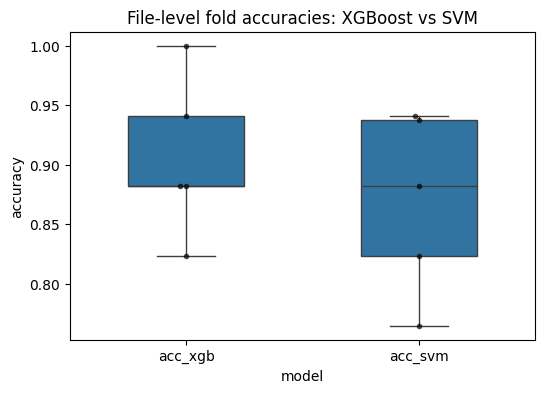

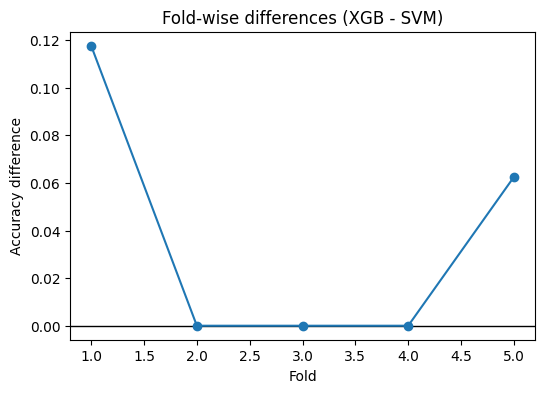

In [12]:
plt.figure(figsize=(6,4))
dfm = results_df.melt(id_vars="fold", value_vars=["acc_xgb", "acc_svm"], var_name="model", value_name="accuracy")
sns.boxplot(data=dfm, x="model", y="accuracy", width=0.5)
sns.swarmplot(data=dfm, x="model", y="accuracy", color="k", size=4, alpha=0.7)
plt.title("File-level fold accuracies: XGBoost vs SVM")
plt.show()

plt.figure(figsize=(6,4))
plt.axhline(0, color="k", lw=1)
plt.plot(results_df["fold"], results_df["diff"], marker="o")
plt.title("Fold-wise differences (XGB - SVM)")
plt.xlabel("Fold"); plt.ylabel("Accuracy difference")
plt.show()